# Car Break-in Analysis in Chapel Hill

This notebook analyzes car break-ins in Chapel Hill, NC. It uses spatio-temporal clustering to identify crime series.

Wheeler, A. P. (2019). Break the chain: Spatio-temporal analysis of residential burglary series. [*Journal of Investigative Psychology and Offender Profiling*](https://onlinelibrary.wiley.com/doi/abs/10.1002/jip.1524), 16(2), 105-121.

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import matplotlib.pyplot as plt
from crimepy.query import query_esri, esri_time, cache_query
from crimepy.geo import pip, base_folium, add_points, save_map
from crimepy.chain import NearChains
from crimepy.time import monthly_data, month_chart, weekly_data, week_chart
import crimepy.cdcplot
from IPython.display import display

# Configuration
CRIME_URL = "https://services2.arcgis.com/7KRXAKALbBGlCW77/arcgis/rest/services/Recoded_Incidents_New/FeatureServer/0/query"
BOUNDARY_URL = "https://gis-portal.townofchapelhill.org/server/rest/services/OpenData/UrbanServiceBoundary/MapServer/0/query"
PROJ_LOCAL = 'EPSG:2264'
CACHE_FILE = '../chapel_hill_crimes.csv'

def fetch_chapel_hill_crimes(start_year=2020):
    all_crimes = []
    end_year = datetime.datetime.now().year
    for year in range(start_year, end_year + 1):
        start_dt = datetime.datetime(year, 1, 1)
        end_dt = datetime.datetime(year + 1, 1, 1)
        where = f"Date_of_Occurrence >= timestamp '{start_dt.strftime('%Y-%m-%d %H:%M:%S')}' AND Date_of_Occurrence < timestamp '{end_dt.strftime('%Y-%m-%d %H:%M:%S')}' AND (Offense LIKE '%VEHICLE%' OR Offense LIKE '%CAR%')"
        year_crimes = query_esri(CRIME_URL, params={'where': where, 'outFields': '*', 'f': 'geojson'})
        if not year_crimes.empty: all_crimes.append(year_crimes)
    return pd.concat(all_crimes, ignore_index=True) if all_crimes else pd.DataFrame()

# Load data
df = cache_query(CACHE_FILE, fetch_chapel_hill_crimes, {'start_year': 2020})
if not isinstance(df, gpd.GeoDataFrame):
    df = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.Longitude, df.Latitude), crs='EPSG:4326')

df['datetime'] = pd.to_datetime(esri_time(df['Date_of_Occurrence']))
boundary_gdf = query_esri(BOUNDARY_URL, params={'where': '1=1', 'outFields': '*', 'f': 'geojson'}).to_crs(PROJ_LOCAL)

# Filter for break-ins
break_in_patterns = ['LARCENY F/VEHICLE', 'LARCENY FROM MOTOR VEHICLE']
gdf_breakins = df[df['Offense'].str.contains('|'.join(break_in_patterns), case=False, na=False)].copy()
gdf_breakins = pip(gdf_breakins.to_crs(PROJ_LOCAL), boundary_gdf)

print(f"Loaded {len(gdf_breakins)} car break-ins within the boundary.")

Loaded 1440 car break-ins within the boundary.


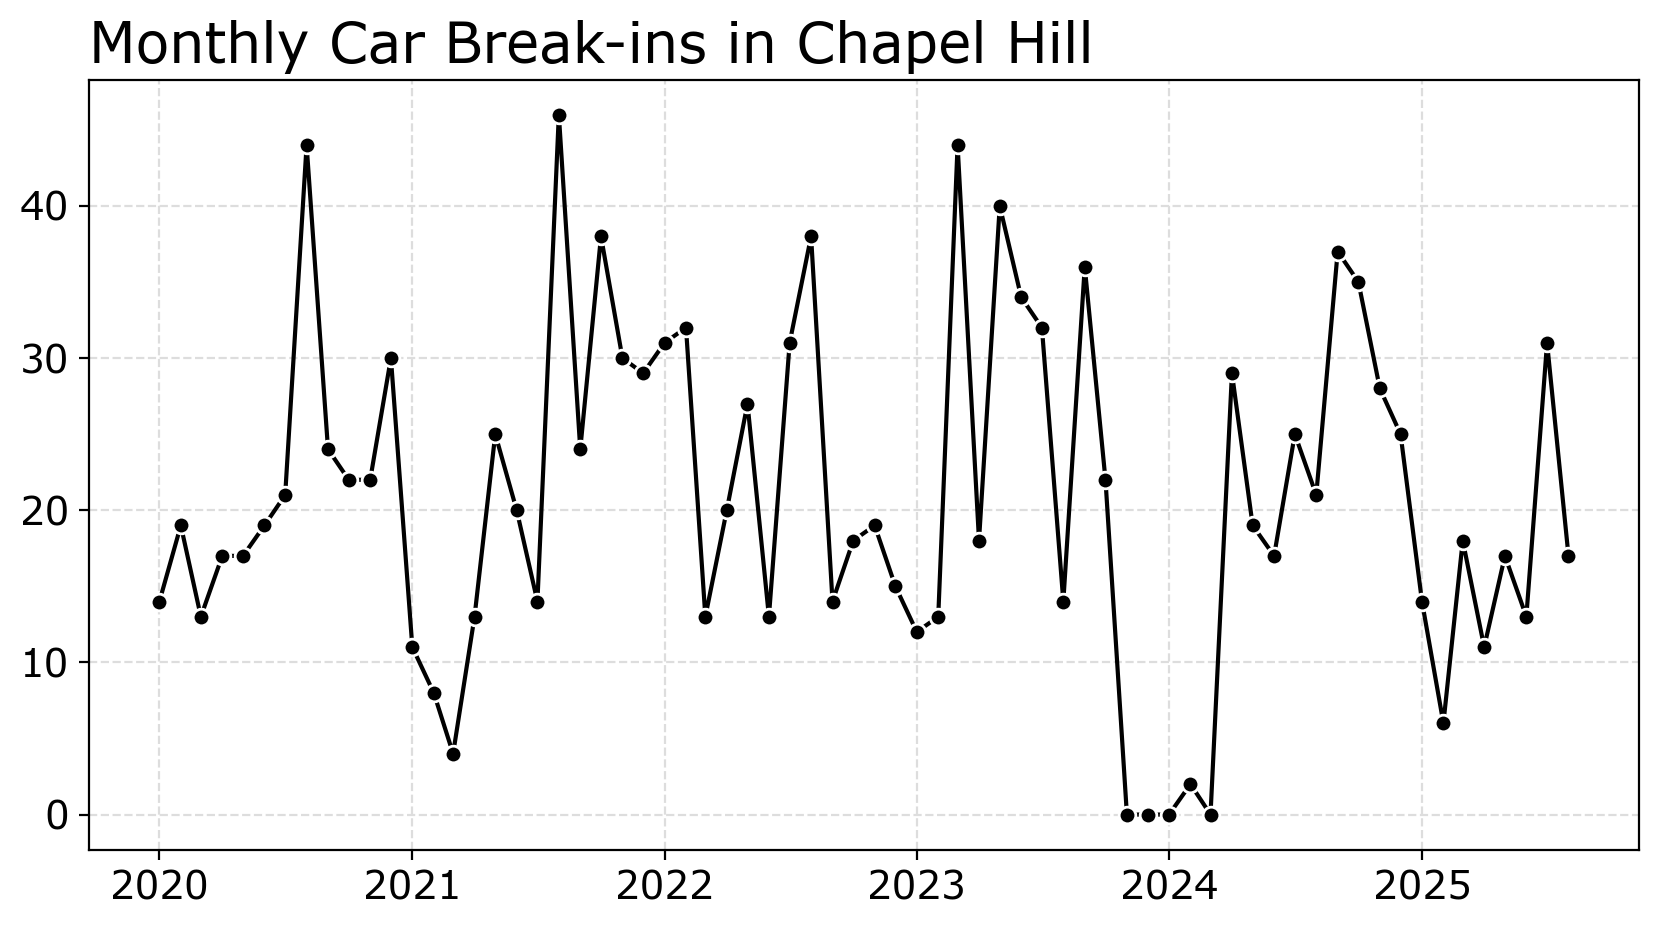

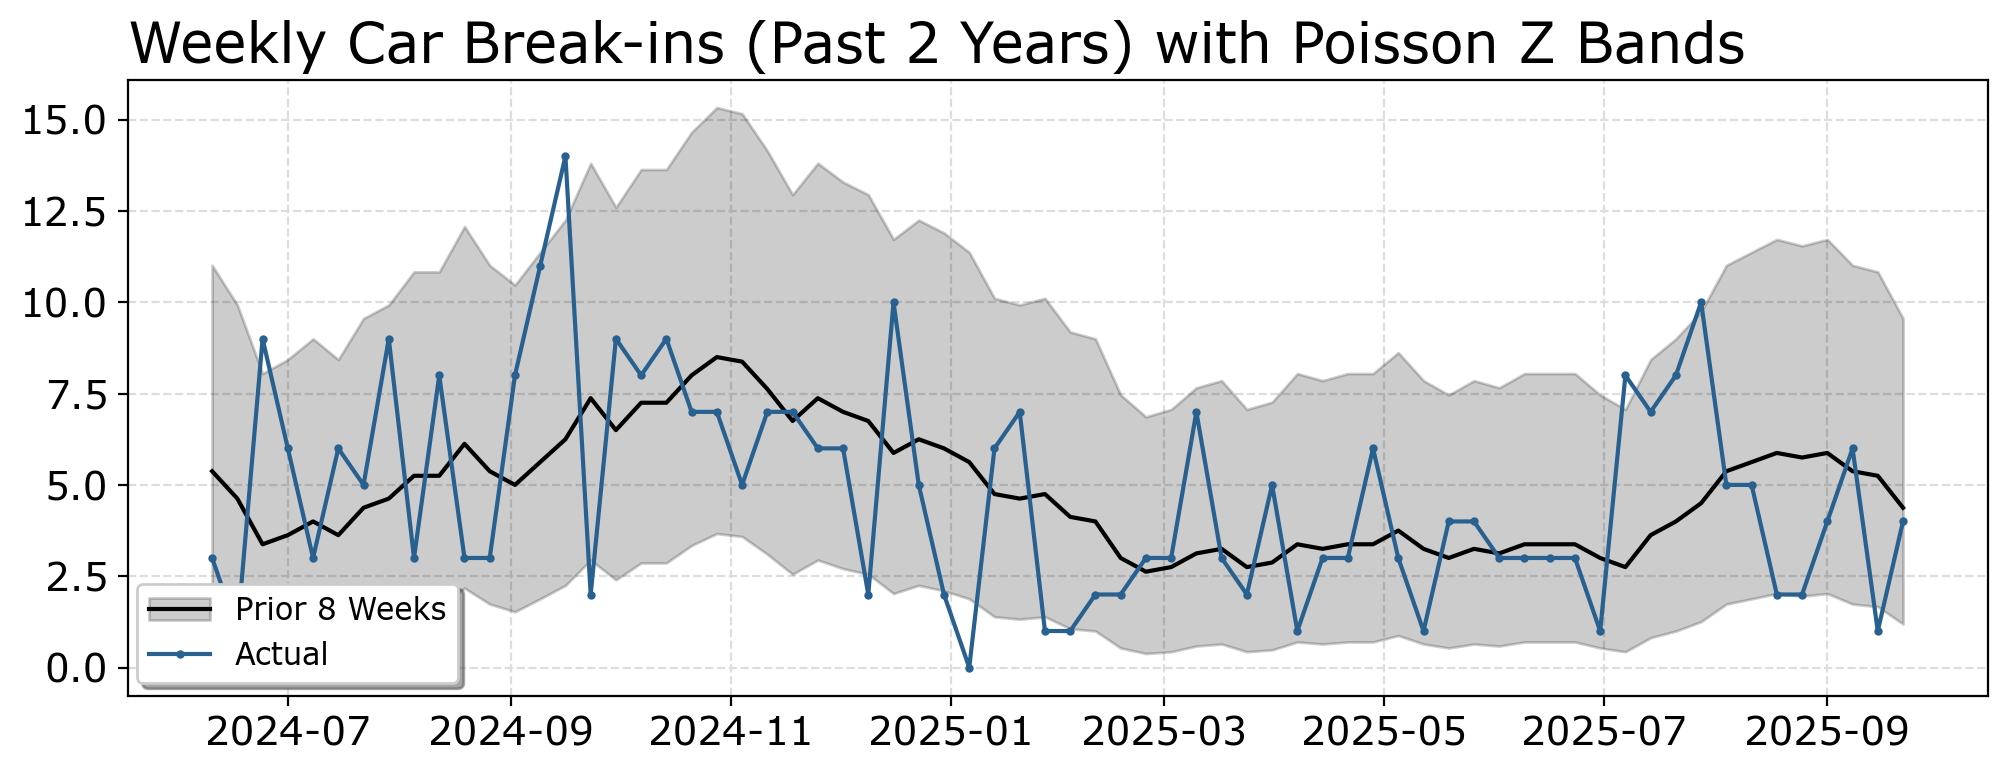

In [2]:
# Monthly chart
m_data = monthly_data(gdf_breakins, 'datetime')
month_chart(m_data, title='Monthly Car Break-ins in Chapel Hill', figsize=(10, 5))

# Weekly chart (Past 2 years)
two_years_ago = datetime.datetime.now() - datetime.timedelta(days=365*2)
w_data = weekly_data(gdf_breakins[gdf_breakins['datetime'] >= two_years_ago], 'datetime', smooth=8, z=2)
week_chart(w_data, title='Weekly Car Break-ins (Past 2 Years) with Poisson Z Bands', figsize=(12, 4))

In [3]:
# Create Folium map
m = base_folium(boundary=boundary_gdf, zoom=12, legend_name="Chapel Hill Boundary")
gdf_4326 = gdf_breakins.to_crs('EPSG:4326').copy()
gdf_4326['lat'] = gdf_4326.geometry.y
gdf_4326['lon'] = gdf_4326.geometry.x

def format_popup(row):
    return f"""
    <div style='font-family: Arial; font-size: 12px; width: 200px;'>
        <h4 style='margin-bottom: 5px; color: #286090;'>{row['Offense']}</h4>
        <hr style='margin: 5px 0;'>
        <b>Incident ID:</b> {row['Incident_ID']}<br>
        <b>Date/Time:</b> {row['datetime'].strftime('%Y-%m-%d %I:%M %p')}<br>
        <b>Street:</b> {row['Street']}
    </div>
    """

gdf_4326['Popup_Text'] = gdf_4326.apply(format_popup, axis=1)
add_points(m, point_df=gdf_4326, lat='lat', lon='lon', html_field='Popup_Text', 
           name="Car Break-ins", cluster=True, show=True, popup_width=250, popup_height=150)

m # Display map in notebook

In [4]:
gdf_breakins['X'] = gdf_breakins.geometry.x
gdf_breakins['Y'] = gdf_breakins.geometry.y

nc = NearChains(gdf_breakins, x='X', y='Y', d='datetime')
clusters = nc.get_clusters(time_thresh=7, space_thresh=1000)

if clusters:
    summary = nc.get_component_summary(clusters)
    # Find the cluster with the latest max_datetime
    latest_cluster_id = summary.sort_values(by='max_datetime', ascending=False).iloc[0]['component_id']
    latest_cluster_df = clusters[latest_cluster_id]
    
    print(f"\nLatest Cluster (ID {latest_cluster_id}):")
    display(latest_cluster_df[['datetime', 'Street', 'Offense']])
else:
    print("No clusters found.")

Found 205 connected components
Processed 523 valid spatiotemporal pairs

Latest Cluster (ID 32):


,datetime,Street,Offense
2840,2025-09-19 16:00:00,303 W FRANKLIN ST,B&E LARCENY F/VEHICLE
2846,2025-09-25 12:00:00,321 W CAMERON AVE,B&E LARCENY F/VEHICLE
2838,2025-09-25 15:00:00,413 YATES MOTOR COMPANY ALY,B&E LARCENY F/VEHICLE
2844,2025-09-26 16:30:00,109 CAMERON GLEN DR,B&E LARCENY F/VEHICLE
